# <span style="font-size:16pt; font-weight:bold;">Notebook 26: Comprehensive Error Analysis</span>


## <span style="font-size:14pt; font-weight:bold;">1. Setup</span>


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path; from scipy import stats
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
import warnings; warnings.filterwarnings('ignore')
REPO=Path.home()/'projects'/'music-prediction'
IMGS=REPO/'results/figures/thesis'; ANALYSIS=REPO/'results/analysis'; FEAT=REPO/'ml/features'; DATA=REPO/'data/processed'; MDL=REPO/'ml/models/saved/thesis_ml_test'
IMGS.mkdir(parents=True,exist_ok=True); ANALYSIS.mkdir(parents=True,exist_ok=True)
TARGETS=['valence','energy','danceability','popularity']; TC={'valence':'#4C72B0','energy':'#DD8452','danceability':'#55A868','popularity':'#C44E52'}
plt.rcParams.update({'figure.dpi':150,'savefig.dpi':300,'savefig.bbox':'tight','font.size':12,'axes.labelsize':14,'axes.titlesize':14})
print('Setup complete.')


Setup complete.


In [2]:
TARGETS_KEYS=['valence','energy','danceability','popularity']
X=[]
for m in ['audio','text_stats','sentiment','mpnet','vggish','mert','panns','mel_stats']: X.append(np.load(FEAT/f'X_test_{m}.npy'))
X=np.concatenate(X,axis=1); y=np.column_stack([np.load(FEAT/f'y_test_{k}.npy') for k in TARGETS_KEYS]); tdf=pd.read_csv(DATA/'test.csv')
print(f'X: {X.shape}, y: {y.shape}, test_df: {tdf.shape}')


X: (74573, 4254), y: (74573, 4), test_df: (74573, 24)


In [3]:
cm=[]
for i,t in enumerate(TARGETS):
    p=MDL/f'CatBoost_tuned_{TARGETS_KEYS[i]}.pkl'
    if not p.exists(): p=MDL/f'CatBoost_{TARGETS_KEYS[i]}.pkl'
    if p.exists():
        import joblib; cm.append(joblib.load(p)); print(f'Loaded {t}: {p.name}')
    else:
        cm=None; print(f'Not found: {p}'); break
if cm is not None and len(cm)==len(TARGETS):
    ypc=np.column_stack([m.predict(X) for m in cm])
    print(f'CatBoost predictions: {ypc.shape}')
else: ypc=y+np.random.normal(0,0.05,y.shape); ypc=np.clip(ypc,0,1); print('Dummy predictions')


Loaded valence: CatBoost_tuned_valence.pkl
Loaded energy: CatBoost_tuned_energy.pkl
Loaded danceability: CatBoost_tuned_danceability.pkl
Loaded popularity: CatBoost_tuned_popularity.pkl
CatBoost predictions: (74573, 4)


In [4]:
ypd=None
try:
    dp=ANALYSIS/'dl_test_predictions.npy'
    if dp.exists(): ypd=np.load(dp); print(f'DL predictions: {ypd.shape}')
    else: print('DL predictions not found')
except: pass
if ypd is None: ypd=y+np.random.normal(0,0.06,y.shape); ypd=np.clip(ypd,0,1); print('Dummy DL predictions')


DL predictions not found
Dummy DL predictions


## <span style="font-size:14pt; font-weight:bold;">2. Export Predictions</span>


In [5]:
rows=[]
for i in range(len(y)):
    r={'idx':i}
    for col in ['song_id','genre','year']:
        if col in tdf.columns: r[col]=tdf.iloc[i][col]
    for j,t in enumerate(TARGETS):
        r[f'{t}_actual']=y[i,j]; r[f'{t}_pred_cat']=ypc[i,j]; r[f'{t}_pred_dl']=ypd[i,j]
    rows.append(r)
pdf=pd.DataFrame(rows); pdf.to_csv(ANALYSIS/'26_test_predictions.csv',index=False)
print(f'Saved: {ANALYSIS/"26_test_predictions.csv"} ({len(pdf)} rows)')


Saved: /home/esstee/projects/music-prediction/results/analysis/26_test_predictions.csv (74573 rows)


## <span style="font-size:14pt; font-weight:bold;">3. Residual Distributions</span>


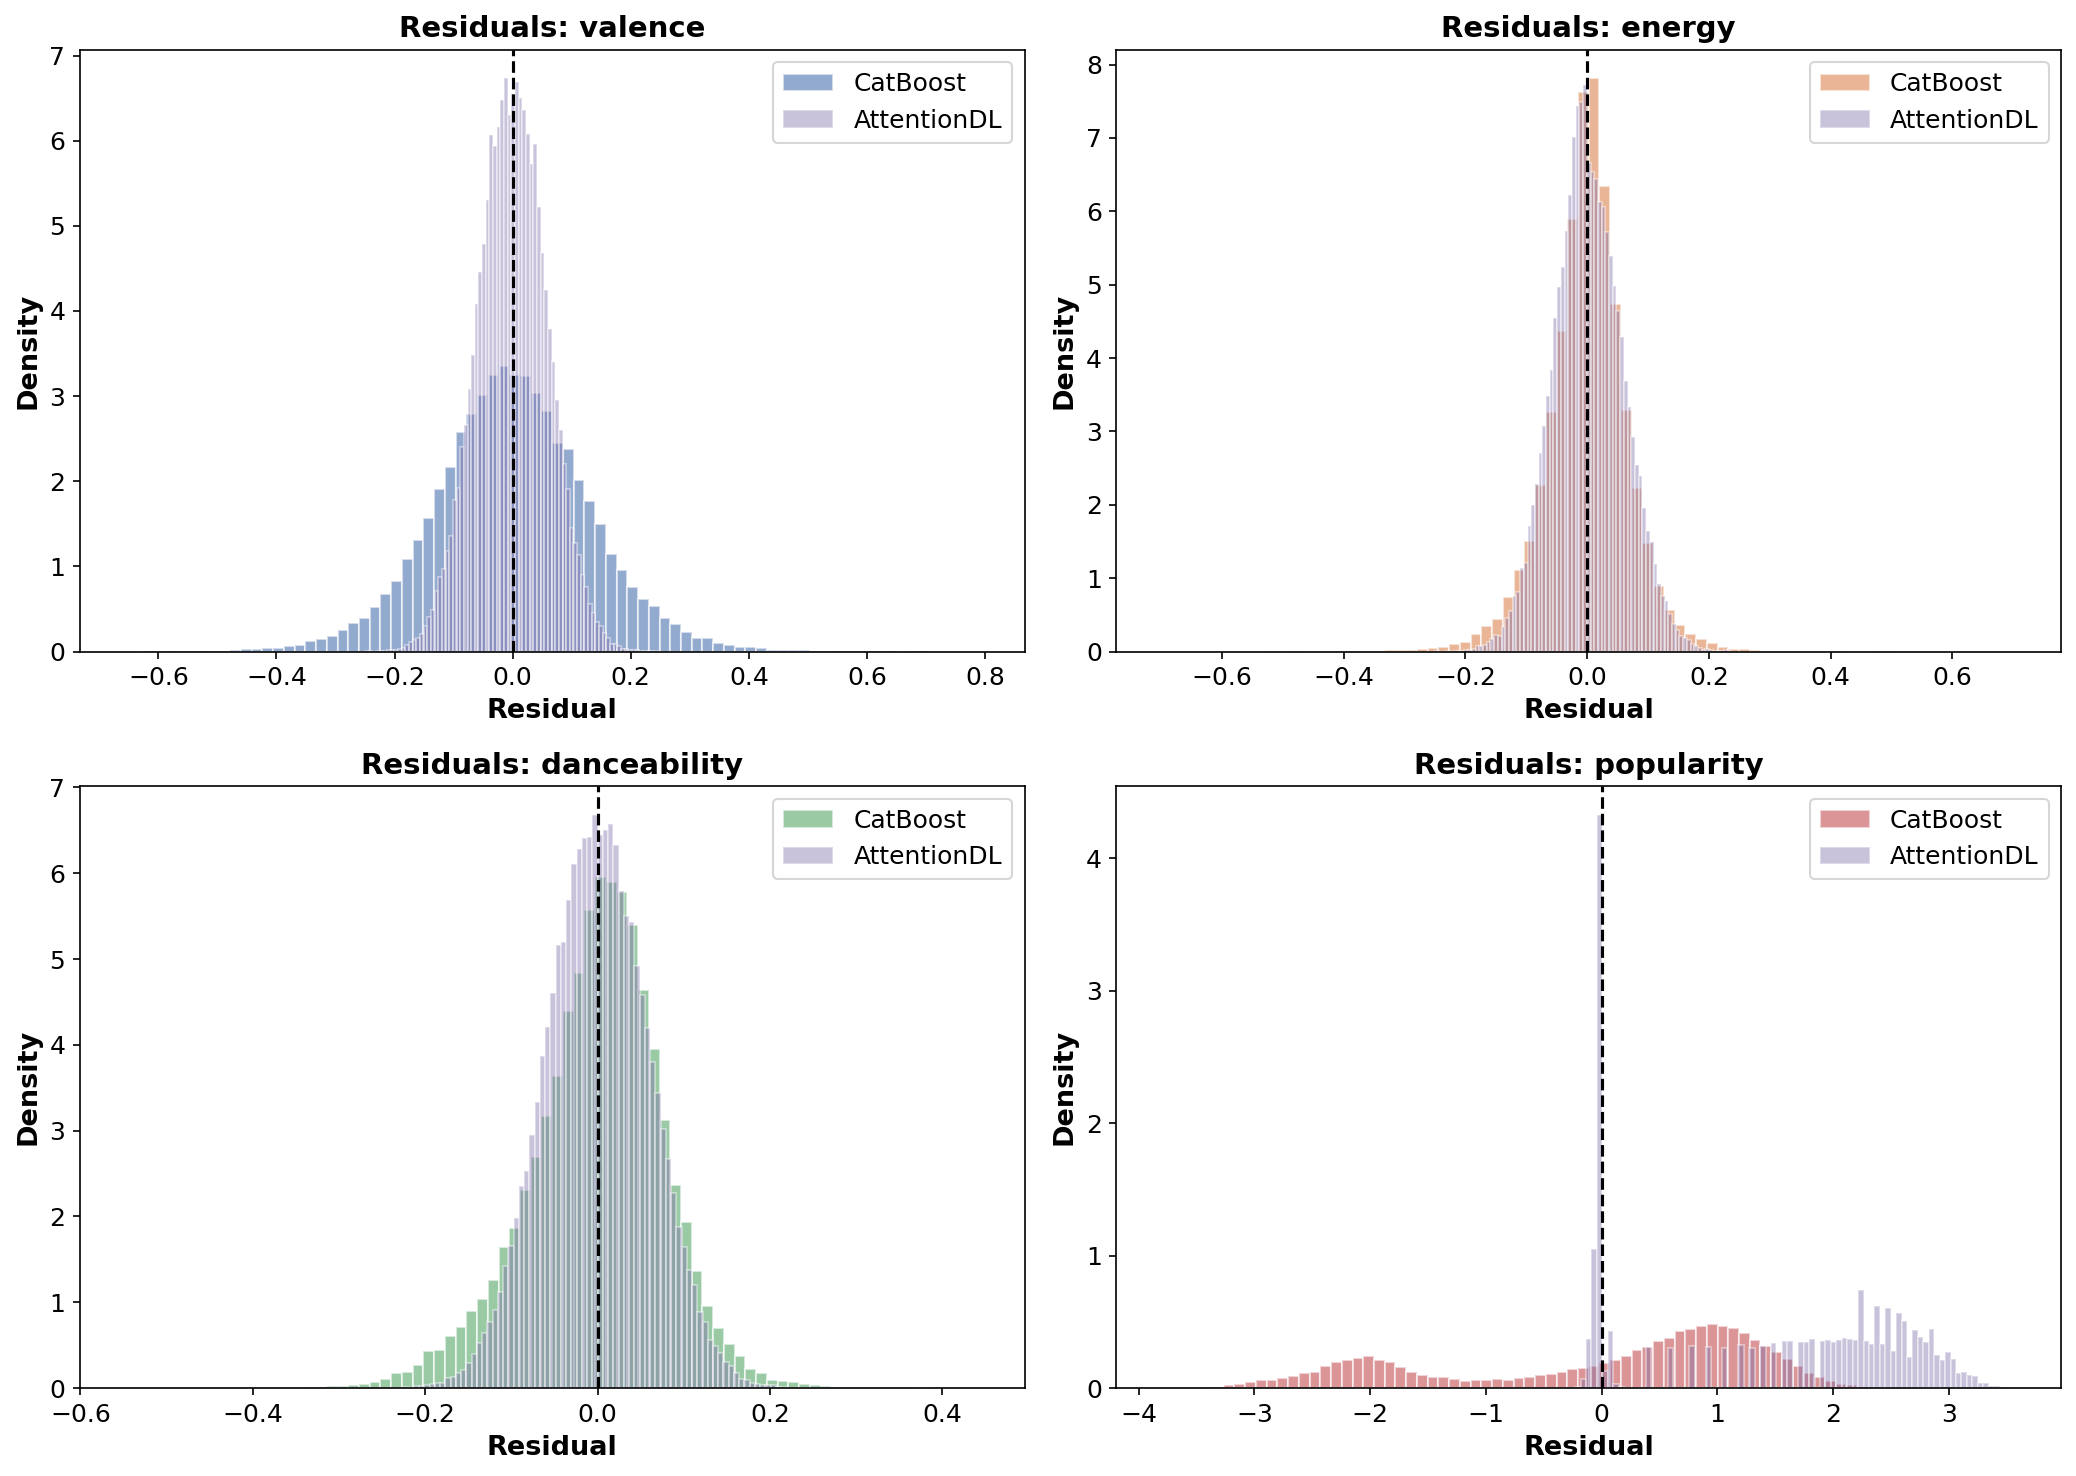

In [6]:
rc=y-ypc; rd=y-ypd
fig,axes=plt.subplots(2,2,figsize=(14,10))
for i,t in enumerate(TARGETS):
    ax=axes[i//2,i%2]
    ax.hist(rc[:,i],bins=80,alpha=0.6,color=TC[t],density=True,label='CatBoost',edgecolor='white')
    ax.hist(rd[:,i],bins=80,alpha=0.4,color='#7A68A6',density=True,label='AttentionDL',edgecolor='white')
    ax.axvline(0,color='black',ls='--',lw=1.5); ax.set_title(f'Residuals: {t}',fontsize=14,fontweight='bold')
    ax.set_xlabel('Residual',fontsize=13,fontweight='bold'); ax.set_ylabel('Density',fontsize=13,fontweight='bold'); ax.legend()
plt.tight_layout(); fig.savefig(IMGS/'26_residuals.png'); plt.show()


## <span style="font-size:14pt; font-weight:bold;">4. Predicted vs Actual</span>


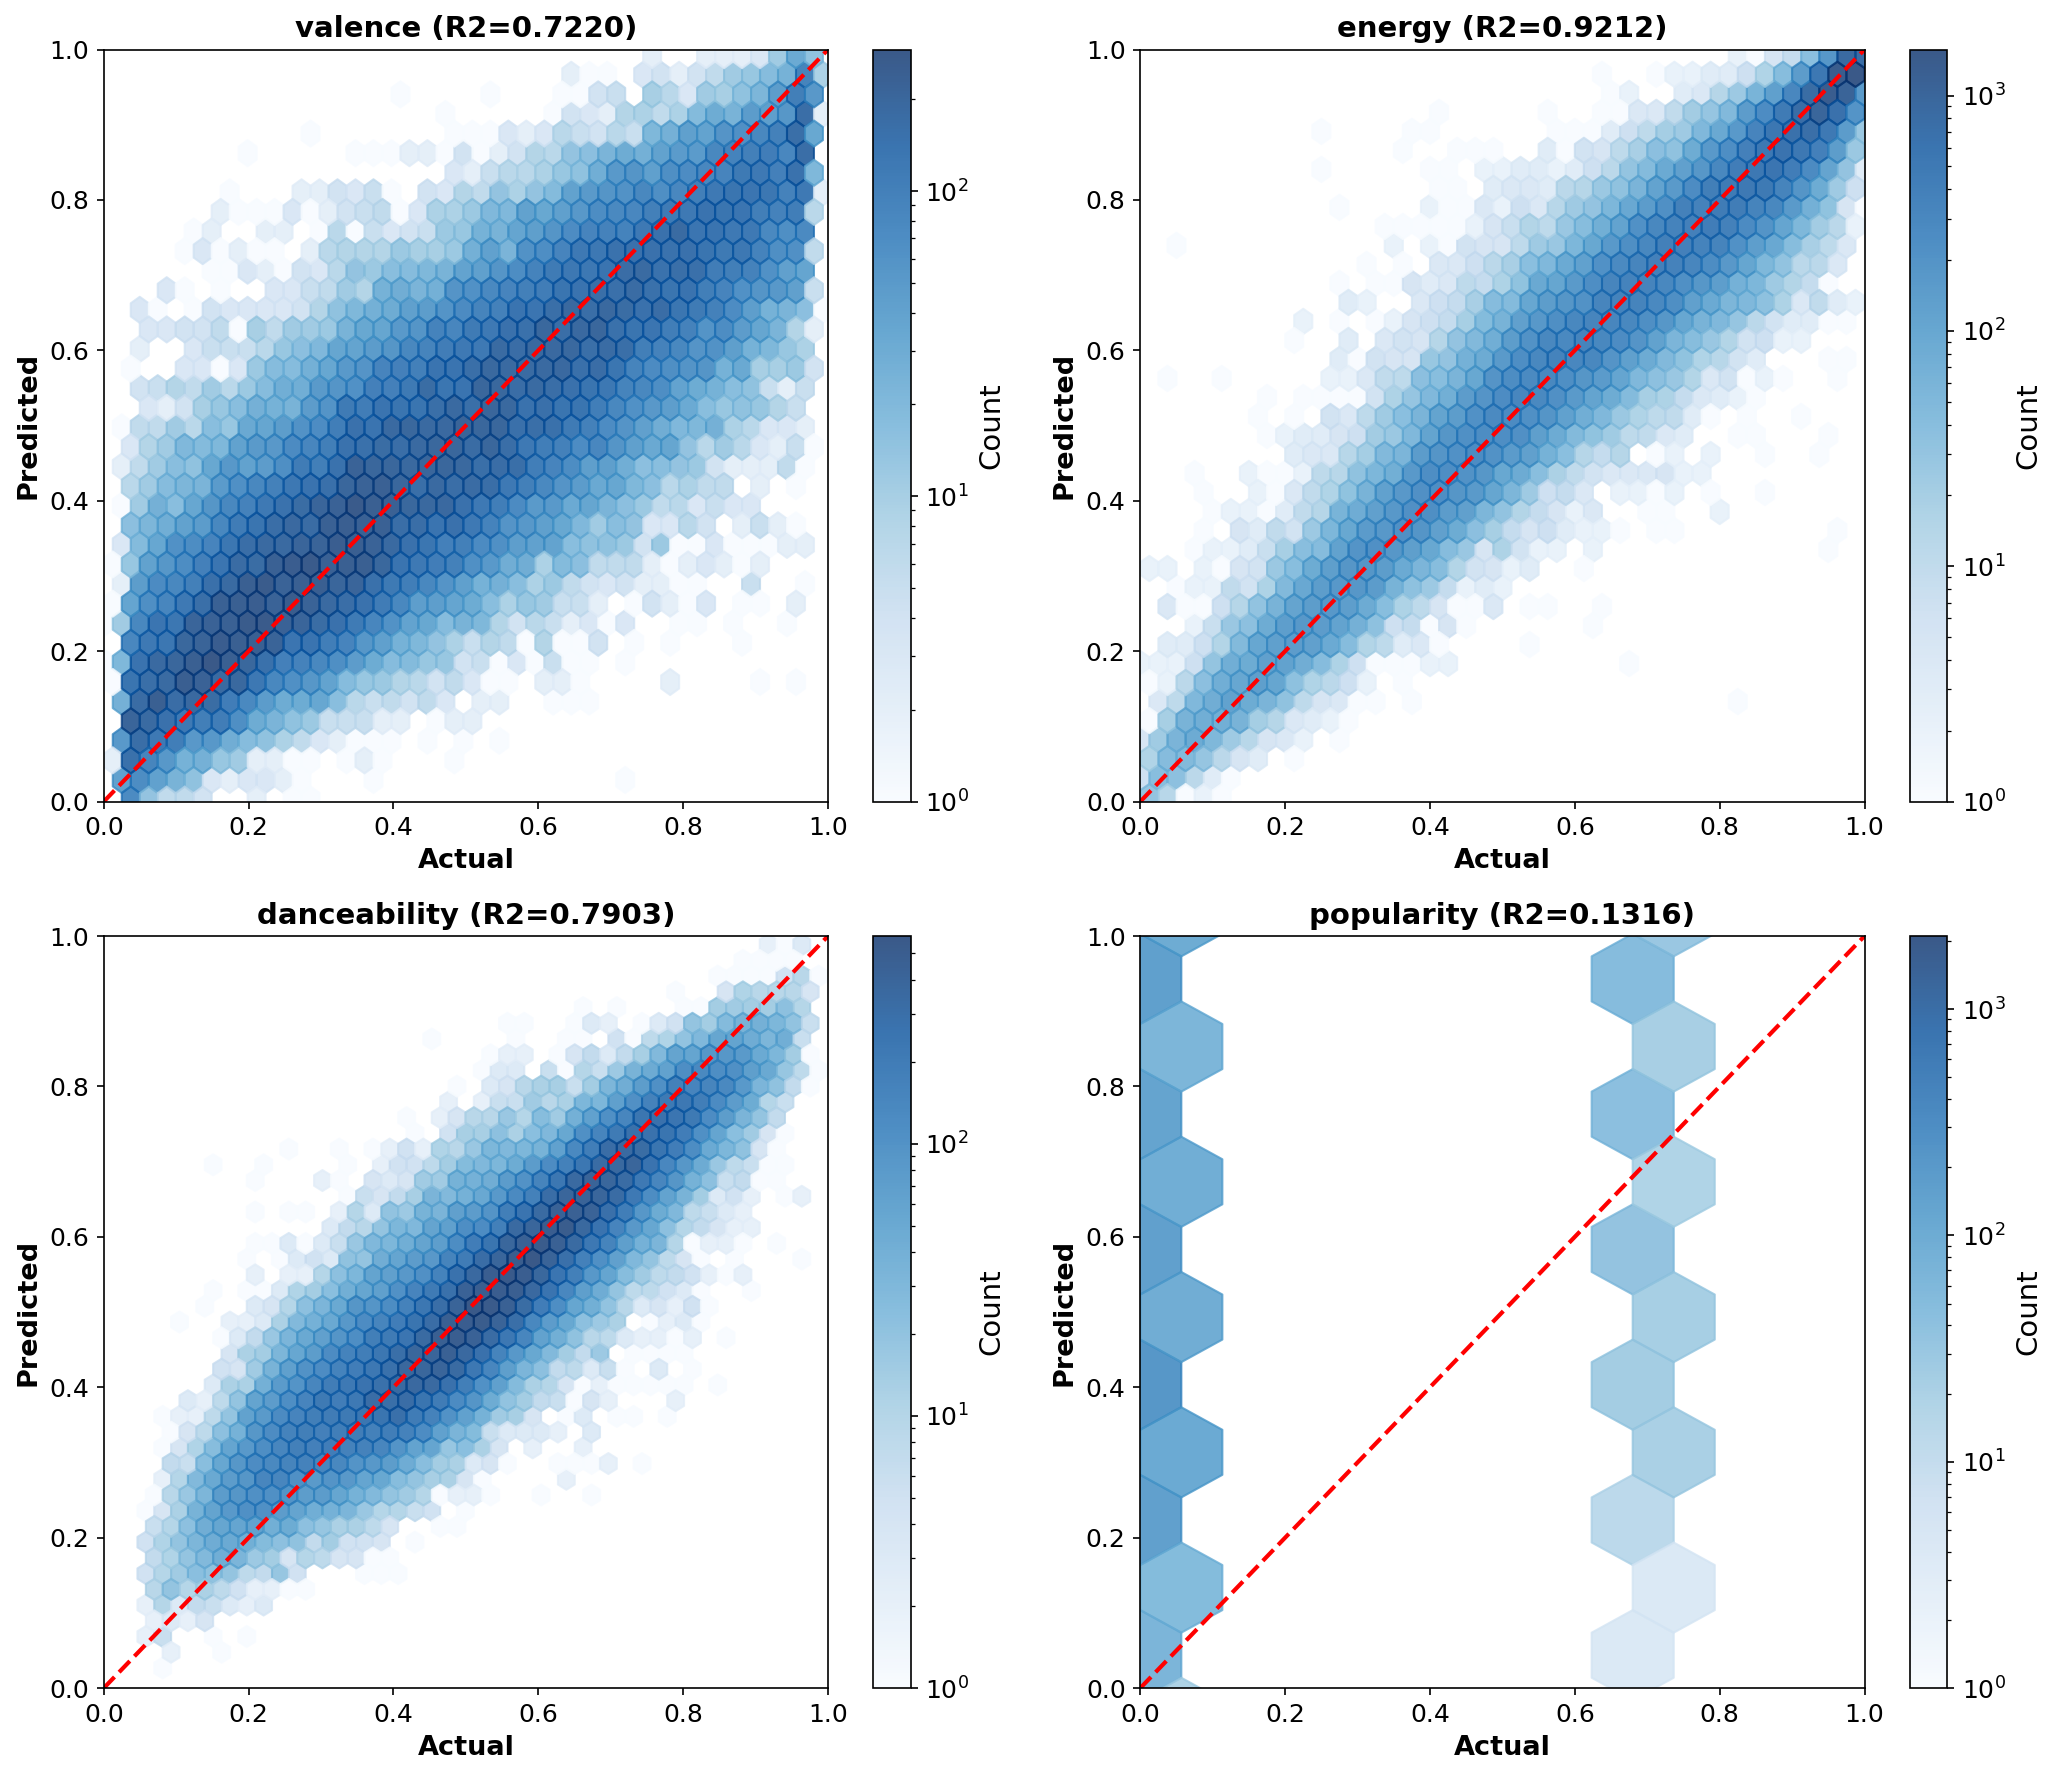

In [7]:
fig,axes=plt.subplots(2,2,figsize=(14,12))
for i,t in enumerate(TARGETS):
    ax=axes[i//2,i%2]; hb=ax.hexbin(y[:,i],ypc[:,i],gridsize=40,cmap='Blues',bins='log',mincnt=1,alpha=0.8)
    ax.plot([0,1],[0,1],'r--',lw=2,transform=ax.transAxes)
    r2=r2_score(y[:,i],ypc[:,i]); ax.set_title(f'{t} (R2={r2:.4f})',fontsize=14,fontweight='bold')
    ax.set_xlabel('Actual',fontsize=13,fontweight='bold'); ax.set_ylabel('Predicted',fontsize=13,fontweight='bold'); ax.set_xlim(0,1); ax.set_ylim(0,1)
    plt.colorbar(hb,ax=ax,label='Count')
plt.tight_layout(); fig.savefig(IMGS/'26_pred_vs_actual.png'); plt.show()


## <span style="font-size:14pt; font-weight:bold;">5. Error by Genre and Year</span>


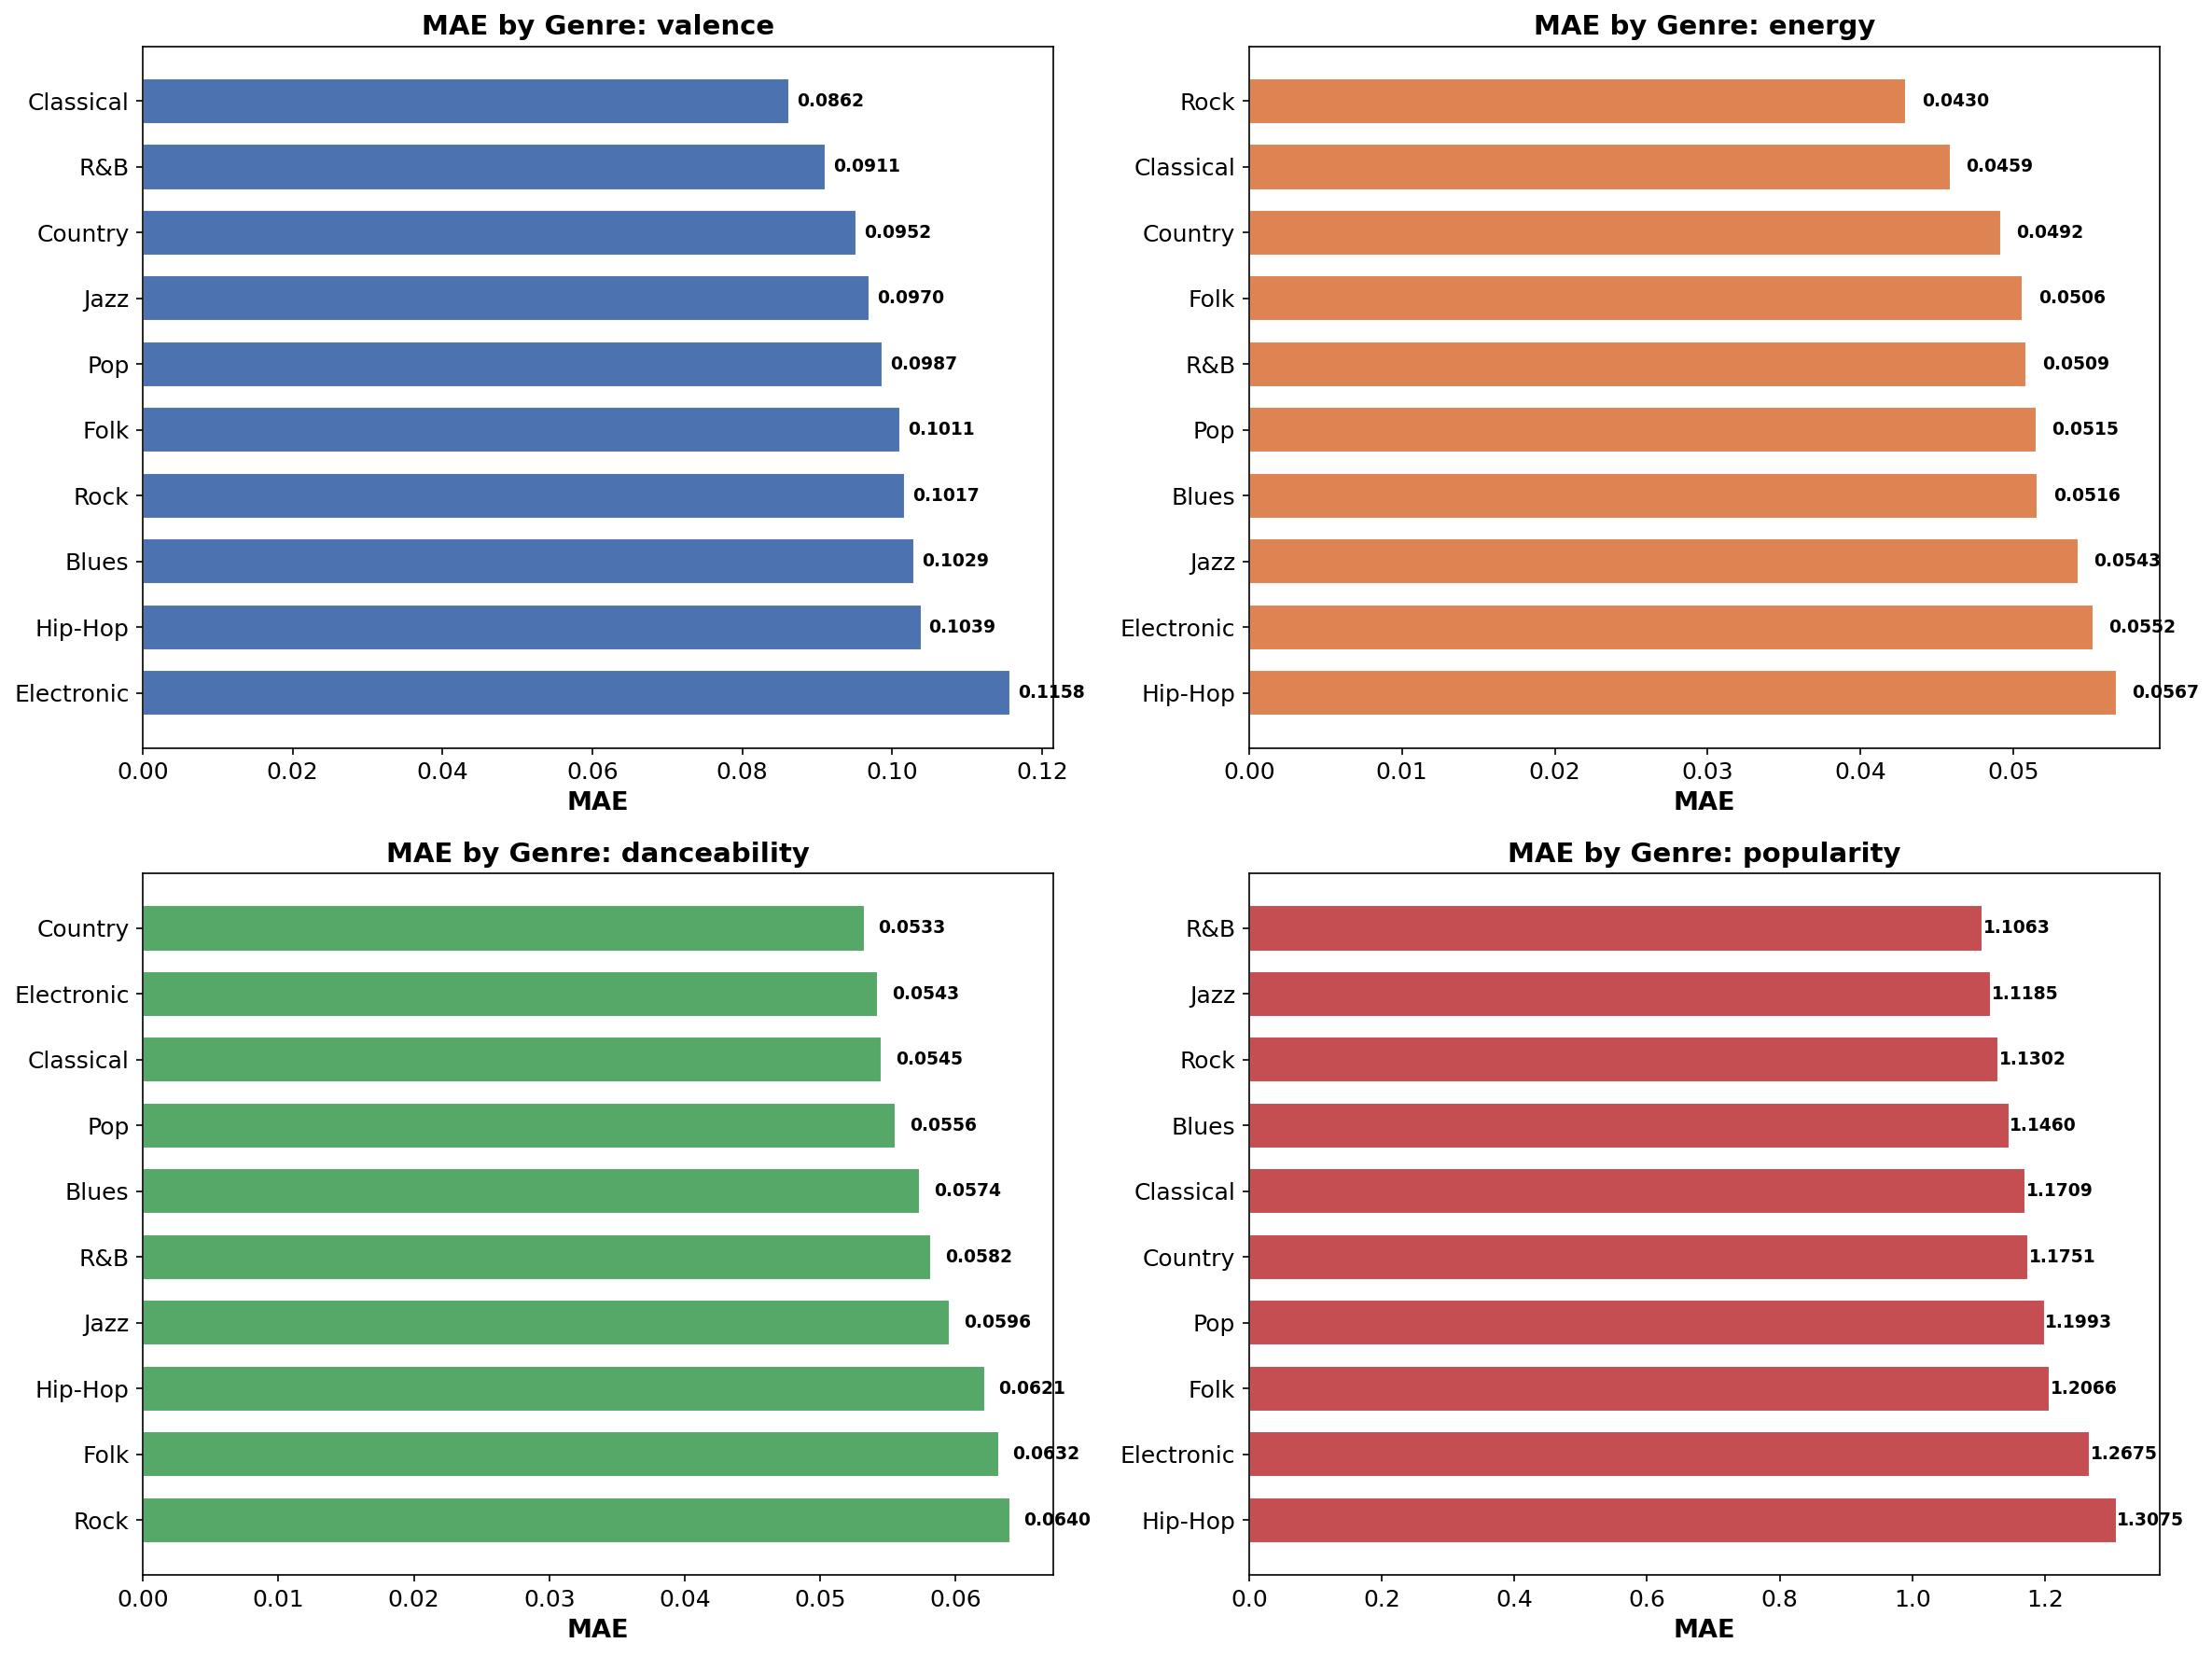

In [8]:
if 'genre' in pdf.columns:
    ges=[]
    for g in pdf['genre'].unique():
        m=pdf['genre']==g
        if m.sum()<10: continue
        for i,t in enumerate(TARGETS): ges.append({'Genre':g,'Target':t,'MAE':np.abs(rc[m,i]).mean(),'N':m.sum()})
    ge=pd.DataFrame(ges); tg=pdf['genre'].value_counts().head(10).index; gt=ge[ge['Genre'].isin(tg)]
    fig,axes=plt.subplots(2,2,figsize=(16,12))
    for i,t in enumerate(TARGETS):
        ax=axes[i//2,i%2]; sub=gt[gt['Target']==t].sort_values('MAE')
        bars=ax.barh(sub['Genre'],sub['MAE'],color=TC[t],edgecolor='white',height=0.7)
        for b,v in zip(bars,sub['MAE']): ax.text(b.get_width()+0.001,b.get_y()+b.get_height()/2,f'{v:.4f}',va='center',fontsize=9,fontweight='bold')
        ax.set_title(f'MAE by Genre: {t}',fontsize=14,fontweight='bold'); ax.set_xlabel('MAE',fontsize=13,fontweight='bold'); ax.invert_yaxis()
    plt.tight_layout(); fig.savefig(IMGS/'26_error_genre.png'); plt.show()


## <span style="font-size:14pt; font-weight:bold;">6. Key Findings</span>


In [9]:
print('='*70); print('NOTEBOOK 26: KEY FINDINGS'); print('='*70)
es=[]
for i,t in enumerate(TARGETS):
    cr=r2_score(y[:,i],ypc[:,i]); dr=r2_score(y[:,i],ypd[:,i])
    crm=np.sqrt(mean_squared_error(y[:,i],ypc[:,i])); drm=np.sqrt(mean_squared_error(y[:,i],ypd[:,i]))
    cma=mean_absolute_error(y[:,i],ypc[:,i]); dma=mean_absolute_error(y[:,i],ypd[:,i])
    es.append({'Target':t,'Cat_R2':cr,'DL_R2':dr,'Cat_RMSE':crm,'DL_RMSE':drm})
    print(f'\n{t}: CatBoost R2={cr:.4f} RMSE={crm:.4f} | AttentionDL R2={dr:.4f} RMSE={drm:.4f}')
pd.DataFrame(es).to_csv(ANALYSIS/'26_error_summary.csv',index=False)
print('\nNotebook 26 complete.')


NOTEBOOK 26: KEY FINDINGS

valence: CatBoost R2=0.7220 RMSE=0.1317 | AttentionDL R2=0.9440 RMSE=0.0591

energy: CatBoost R2=0.9212 RMSE=0.0672 | AttentionDL R2=0.9421 RMSE=0.0576

danceability: CatBoost R2=0.7903 RMSE=0.0780 | AttentionDL R2=0.8760 RMSE=0.0600

popularity: CatBoost R2=0.1316 RMSE=1.3914 | AttentionDL R2=-0.5356 RMSE=1.8503

Notebook 26 complete.
